# NB8: Consolidated Feature CSV + Outlier Trimming Analysis

**Author:** Keshav, IIT Bombay (MEMS, DDP under Prof. Amrita Bhattacharya)  
**Date:** March 2026  
**Purpose:**  
1. Create a single consolidated CSV with the best ~20 features (both 99-row and 205-row versions)  
2. Analyze the effect of removing high-alpha_R outliers (>3.0, >3.5) on regression and classification performance  

**Location:** `k-path/old+new_nb6/` (next to nb7)  
**Outputs:** `nb8_consolidated_and_outlier_analysis-results/`

## 0. Config -- SET ALL PATHS HERE

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PATH CONFIG -- Update these if the notebook is moved
# ============================================================

# Root of the DDP project
DDP_ROOT = '../../'  # nb8 is in k-path/old+new_nb6/, so ../../ = Keshav-DDP/

# Master dataset (205 rows, 99 UIDs)
RASHBA_CSV = os.path.join(DDP_ROOT, 'Data/rashba.csv')

# nb1 output: p-orbital fractions (99 rows, 1.0 eV window)
# This should have columns: uid (or Formula), E_pfrac_VBM, E_pfrac_CBM
# UPDATE this path to point to nb1's output CSV with p-fractions at 1.0 eV
NB1_PFRAC_CSV = os.path.join(DDP_ROOT, 'Weight-contribution/contribution-model/nb1_descriptor_extraction-results/pfrac_1.0eV.csv')

# nb1.5 output: s/d orbital fractions (99 rows)
# Should have: uid, E_sfrac_VBM, E_sfrac_CBM, E_dfrac_VBM, E_dfrac_CBM
NB1_5_SDFRAC_CSV = os.path.join(DDP_ROOT, 'Weight-contribution/contribution-model/nb1.5_sd_orbital_fraction-results/sd_fractions_1.0eV.csv')

# nb5/nb7 merged descriptor CSV (205 rows, plane-based k-path descriptors)
# Should have: uid, kpath, band, pmid_afs_gauss_std, kpath_angle_deg, etc.
NB7_DESCRIPTORS_CSV = os.path.join(DDP_ROOT, 'k-path/old+new_nb6/rashba_206_all_descriptors.csv')

# Output directory for this notebook
RESULTS_DIR = 'nb8_consolidated_and_outlier_analysis-results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Config loaded. Checking paths...')
for name, path in [('RASHBA_CSV', RASHBA_CSV), ('NB1_PFRAC', NB1_PFRAC_CSV),
                    ('NB1_5_SDFRAC', NB1_5_SDFRAC_CSV), ('NB7_DESC', NB7_DESCRIPTORS_CSV)]:
    exists = os.path.exists(path)
    print(f'  {name}: {path} --> {"FOUND" if exists else "NOT FOUND -- update path!"}')

print(f'\nResults will be saved to: {RESULTS_DIR}/')

Config loaded. Checking paths...
  RASHBA_CSV: ../../Data/rashba.csv --> FOUND
  NB1_PFRAC: ../../Weight-contribution/contribution-model/nb1_descriptor_extraction-results/pfrac_1.0eV.csv --> NOT FOUND -- update path!
  NB1_5_SDFRAC: ../../Weight-contribution/contribution-model/nb1.5_sd_orbital_fraction-results/sd_fractions_1.0eV.csv --> NOT FOUND -- update path!
  NB7_DESC: ../../k-path/old+new_nb6/rashba_206_all_descriptors.csv --> FOUND

Results will be saved to: nb8_consolidated_and_outlier_analysis-results/


## 1. Load and Inspect All Source Files

In [2]:
import pandas as pd
import numpy as np

# --- Load master rashba.csv ---
rashba = pd.read_csv(RASHBA_CSV)
print(f'rashba.csv: {rashba.shape[0]} rows, {rashba.shape[1]} cols')
print(f'  Columns: {list(rashba.columns)}')
print(f'  UIDs: {rashba["uid"].nunique()}')
print(f'  alpha_R range: [{rashba["Rashba_parameter"].min():.3f}, {rashba["Rashba_parameter"].max():.3f}]')
print(f'  alpha_R > 3.0: {(rashba.groupby("uid")["Rashba_parameter"].max() > 3.0).sum()} compounds')
print(f'  alpha_R > 3.5: {(rashba.groupby("uid")["Rashba_parameter"].max() > 3.5).sum()} compounds')
print()

rashba.csv: 205 rows, 11 cols
  Columns: ['Formula', 'uid', 'spacegroup', 'ehull', 'bandgap', 'band', 'kpath', 'Rashba_parameter', 'SS', 'dE', 'anticrossing']
  UIDs: 99
  alpha_R range: [0.393, 4.804]
  alpha_R > 3.0: 12 compounds
  alpha_R > 3.5: 8 compounds



In [3]:
# --- Load nb7 descriptors (205 rows, has k-path features) ---
desc_205 = pd.read_csv(NB7_DESCRIPTORS_CSV)
print(f'nb7 descriptors: {desc_205.shape[0]} rows, {desc_205.shape[1]} cols')
print(f'  Sample columns: {list(desc_205.columns[:20])}...')
print()

nb7 descriptors: 205 rows, 134 cols
  Sample columns: ['Formula', 'uid', 'kpath', 'Rashba_parameter', 'band_binary', 'bandgap', 'ehull', 'kpath_real_distance', 'kpath_angle_deg', 'kvec_x', 'kvec_y', 'kvec_z', 'kstart_frac_x', 'kstart_frac_y', 'kend_frac_x', 'kend_frac_y', 'kmid_frac_x', 'kmid_frac_y', 'kstart_degen', 'kend_degen']...



In [4]:
# --- Load nb1 p-fractions (99 rows) ---
try:
    pfrac = pd.read_csv(NB1_PFRAC_CSV)
    print(f'nb1 p-fractions: {pfrac.shape[0]} rows, {pfrac.shape[1]} cols')
    print(f'  Columns: {list(pfrac.columns)}')
except FileNotFoundError:
    pfrac = None
    print('nb1 p-fractions: NOT FOUND -- will try to extract from nb7 descriptors')
print()

nb1 p-fractions: NOT FOUND -- will try to extract from nb7 descriptors



In [5]:
# --- Load nb1.5 s/d fractions (99 rows) ---
try:
    sdfrac = pd.read_csv(NB1_5_SDFRAC_CSV)
    print(f'nb1.5 s/d fractions: {sdfrac.shape[0]} rows, {sdfrac.shape[1]} cols')
    print(f'  Columns: {list(sdfrac.columns)}')
except FileNotFoundError:
    sdfrac = None
    print('nb1.5 s/d fractions: NOT FOUND -- s/d features will be missing from consolidated CSV')
print()

nb1.5 s/d fractions: NOT FOUND -- s/d features will be missing from consolidated CSV



## 2. Build Consolidated CSV

Target features (~20):

| # | Feature | Source | In winning 6? |
|---|---------|--------|---------------|
| 1 | E_pfrac_VBM | nb1 / nb7 | YES |
| 2 | E_pfrac_CBM | nb1 / nb7 | YES |
| 3 | radius_mean | nb5 / nb7 | YES |
| 4 | pmid_afs_gauss_std | nb5 / nb7 | YES |
| 5 | kpath_angle_deg | nb5 / nb7 | YES |
| 6 | ehull | rashba.csv | YES |
| 7 | E_sfrac_VBM | nb1.5 | no (best single feat, r=0.52) |
| 8 | E_sfrac_CBM | nb1.5 | no |
| 9 | E_dfrac_VBM | nb1.5 | no |
| 10 | E_dfrac_CBM | nb1.5 | no |
| 11 | max_Z4 | nb5 / nb7 | no (C6 7th feat) |
| 12 | max_Z | nb5 / nb7 | no |
| 13 | pmid_grdf_trig_max | nb5 / nb7 | no |
| 14 | bandgap | rashba.csv | no |
| 15 | band_binary | nb5 / nb7 | no (205-row only) |
| 16 | radius_diff | nb5 / nb7 | no |
| 17 | max_mass | nb5 / nb7 | no |
| 18 | kpath_real_distance | nb5 / nb7 | no |
| 19 | n_elements | nb5 / nb7 | no |
| 20 | E_pfrac_relevant | nb5 / nb7 | no (205-row version) |

In [6]:
# Features we want in the consolidated CSV
# These are the column names as they appear in the source files.
# If a name doesn't match, we'll handle it below.

# Identity columns
ID_COLS = ['Formula', 'uid', 'kpath', 'band']
TARGET_COL = 'Rashba_parameter'

# Features to include
FEATURES_FROM_RASHBA = ['ehull', 'bandgap']

FEATURES_FROM_NB7 = [
    # Winning 6 (except ehull which comes from rashba.csv)
    'E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean',
    'pmid_afs_gauss_std', 'kpath_angle_deg',
    # Other useful features
    'max_Z4', 'max_Z', 'max_mass',
    'pmid_grdf_trig_max',
    'band_binary', 'radius_diff', 'n_elements',
    'kpath_real_distance',
    'E_pfrac_relevant',  # picks VBM or CBM based on band type
]

FEATURES_FROM_NB1_5 = [
    'E_sfrac_VBM', 'E_sfrac_CBM',
    'E_dfrac_VBM', 'E_dfrac_CBM',
]

print(f'Target feature count: {len(FEATURES_FROM_RASHBA) + len(FEATURES_FROM_NB7) + len(FEATURES_FROM_NB1_5)}')

Target feature count: 20


In [7]:
# ============================================================
# Build 205-row consolidated CSV
# ============================================================

# Start with rashba.csv identity + target + direct features
consol_205 = rashba[ID_COLS + [TARGET_COL] + FEATURES_FROM_RASHBA].copy()
print(f'Base from rashba.csv: {consol_205.shape}')

# --- Merge nb7 descriptors ---
# nb7 should have uid + kpath + band as merge keys (or a row index matching rashba.csv)
# Let's figure out the best merge strategy
print(f'\nnb7 columns available for merge keys: ', end='')
potential_keys = [c for c in ['uid', 'Formula', 'kpath', 'band', 'UID'] if c in desc_205.columns]
print(potential_keys)

# Check which target features exist in nb7
found_in_nb7 = [f for f in FEATURES_FROM_NB7 if f in desc_205.columns]
missing_from_nb7 = [f for f in FEATURES_FROM_NB7 if f not in desc_205.columns]
print(f'Found in nb7: {len(found_in_nb7)}/{len(FEATURES_FROM_NB7)}')
if missing_from_nb7:
    print(f'  Missing: {missing_from_nb7}')
    # Try fuzzy match
    for m in missing_from_nb7:
        close = [c for c in desc_205.columns if m.lower() in c.lower() or c.lower() in m.lower()]
        if close:
            print(f'  Possible match for "{m}": {close}')

Base from rashba.csv: (205, 7)

nb7 columns available for merge keys: ['uid', 'Formula', 'kpath']
Found in nb7: 14/14


In [8]:
# Merge nb7 features into the consolidated df
# Strategy: merge on [uid, kpath, band] if all exist, else try [uid] + row alignment

merge_keys = [k for k in ['uid', 'kpath', 'band'] if k in desc_205.columns]
print(f'Merging on keys: {merge_keys}')

if len(merge_keys) >= 2:
    # Preferred: multi-key merge
    nb7_subset = desc_205[merge_keys + found_in_nb7].copy()
    consol_205 = consol_205.merge(nb7_subset, on=merge_keys, how='left')
    print(f'After nb7 merge: {consol_205.shape}')
elif len(merge_keys) == 1:
    # Fallback: single key (will duplicate if 205 rows)
    nb7_subset = desc_205[merge_keys + found_in_nb7].copy()
    consol_205 = consol_205.merge(nb7_subset, on=merge_keys, how='left')
    print(f'After nb7 merge (single key): {consol_205.shape}')
else:
    # Last resort: assume row alignment
    print('WARNING: No common merge keys found. Assuming row alignment (risky!).')
    print('Please verify that nb7 descriptors are in the same row order as rashba.csv.')
    for f in found_in_nb7:
        if len(desc_205) == len(consol_205):
            consol_205[f] = desc_205[f].values
        else:
            print(f'  Row count mismatch ({len(desc_205)} vs {len(consol_205)}), skipping {f}')

# Check for NaN introduced by merge
nan_counts = consol_205[found_in_nb7].isna().sum()
if nan_counts.sum() > 0:
    print(f'\nNaN after merge:')
    print(nan_counts[nan_counts > 0])

Merging on keys: ['uid', 'kpath']
After nb7 merge: (235, 21)


In [9]:
# --- Merge nb1.5 s/d fractions (99 rows -> broadcast to 205 via uid) ---
if sdfrac is not None:
    # Identify uid column in sdfrac
    uid_col_sd = 'uid' if 'uid' in sdfrac.columns else ('UID' if 'UID' in sdfrac.columns else None)
    if uid_col_sd is None:
        # Try Formula
        uid_col_sd = 'Formula' if 'Formula' in sdfrac.columns else None
    
    if uid_col_sd:
        found_sd = [f for f in FEATURES_FROM_NB1_5 if f in sdfrac.columns]
        missing_sd = [f for f in FEATURES_FROM_NB1_5 if f not in sdfrac.columns]
        print(f's/d fractions: found {found_sd}, missing {missing_sd}')
        if missing_sd:
            print(f'  Available cols in sdfrac: {list(sdfrac.columns)}')
        
        if found_sd:
            sd_subset = sdfrac[[uid_col_sd] + found_sd].copy()
            if uid_col_sd != 'uid':
                sd_subset = sd_subset.rename(columns={uid_col_sd: 'uid'})
            consol_205 = consol_205.merge(sd_subset, on='uid', how='left')
            print(f'After s/d merge: {consol_205.shape}')
    else:
        print('WARNING: Cannot find uid/Formula column in sdfrac. Skipping s/d features.')
        print(f'  sdfrac columns: {list(sdfrac.columns)}')
else:
    print('s/d fractions not loaded. These features will be missing.')
    print('To fix: update NB1_5_SDFRAC_CSV path in the config cell.')

s/d fractions not loaded. These features will be missing.
To fix: update NB1_5_SDFRAC_CSV path in the config cell.


In [10]:
# --- Also try to get p-fractions from nb1 if they weren't in nb7 ---
if 'E_pfrac_VBM' not in consol_205.columns and pfrac is not None:
    uid_col_pf = 'uid' if 'uid' in pfrac.columns else ('UID' if 'UID' in pfrac.columns else None)
    if uid_col_pf:
        pf_feats = [f for f in ['E_pfrac_VBM', 'E_pfrac_CBM'] if f in pfrac.columns]
        pf_sub = pfrac[[uid_col_pf] + pf_feats].copy()
        if uid_col_pf != 'uid':
            pf_sub = pf_sub.rename(columns={uid_col_pf: 'uid'})
        consol_205 = consol_205.merge(pf_sub, on='uid', how='left')
        print(f'Added p-fractions from nb1: {pf_feats}')
elif 'E_pfrac_VBM' in consol_205.columns:
    print('E_pfrac_VBM already present from nb7 merge.')
else:
    print('WARNING: E_pfrac_VBM/CBM not available. Check NB1_PFRAC_CSV or NB7_DESCRIPTORS_CSV.')

E_pfrac_VBM already present from nb7 merge.


In [11]:
# --- Final 205-row consolidated CSV ---
print('=== 205-row Consolidated CSV ===')
print(f'Shape: {consol_205.shape}')
print(f'\nColumns ({len(consol_205.columns)}):')
for i, c in enumerate(consol_205.columns):
    nan_pct = consol_205[c].isna().mean() * 100
    nan_str = f' ({nan_pct:.0f}% NaN)' if nan_pct > 0 else ''
    print(f'  {i+1:2d}. {c}{nan_str}')

consol_205_path = os.path.join(RESULTS_DIR, 'rashba_consolidated_205.csv')
consol_205.to_csv(consol_205_path, index=False)
print(f'\nSaved: {consol_205_path}')

=== 205-row Consolidated CSV ===
Shape: (235, 21)

Columns (21):
   1. Formula
   2. uid
   3. kpath
   4. band
   5. Rashba_parameter
   6. ehull
   7. bandgap
   8. E_pfrac_VBM
   9. E_pfrac_CBM
  10. radius_mean
  11. pmid_afs_gauss_std
  12. kpath_angle_deg
  13. max_Z4
  14. max_Z
  15. max_mass
  16. pmid_grdf_trig_max
  17. band_binary
  18. radius_diff
  19. n_elements
  20. kpath_real_distance
  21. E_pfrac_relevant

Saved: nb8_consolidated_and_outlier_analysis-results/rashba_consolidated_205.csv


In [12]:
# ============================================================
# Build 99-row consolidated CSV (max alpha_R per compound)
# ============================================================

# Take the row with max Rashba_parameter per uid
idx_max = consol_205.groupby('uid')['Rashba_parameter'].idxmax()
consol_99 = consol_205.loc[idx_max].copy().reset_index(drop=True)

# For 99-row analysis:
# - E_pfrac_relevant is redundant (we have VBM + CBM separately)
# - band_binary is meaningless (always corresponds to the max-alpha band)
# Keep them in the CSV but note this.

print(f'=== 99-row Consolidated CSV ===')
print(f'Shape: {consol_99.shape}')
print(f'UIDs: {consol_99["uid"].nunique()}')
print(f'alpha_R range: [{consol_99["Rashba_parameter"].min():.3f}, {consol_99["Rashba_parameter"].max():.3f}]')

consol_99_path = os.path.join(RESULTS_DIR, 'rashba_consolidated_99.csv')
consol_99.to_csv(consol_99_path, index=False)
print(f'Saved: {consol_99_path}')

=== 99-row Consolidated CSV ===
Shape: (99, 21)
UIDs: 99
alpha_R range: [0.393, 4.804]
Saved: nb8_consolidated_and_outlier_analysis-results/rashba_consolidated_99.csv


In [13]:
# Quick sanity: show the high-alpha compounds that will be trimmed
high_alpha = consol_99[consol_99['Rashba_parameter'] > 3.0].sort_values('Rashba_parameter', ascending=False)
print(f'Compounds with alpha_R > 3.0 ({len(high_alpha)} total):')
print(high_alpha[['Formula', 'uid', 'Rashba_parameter', 'kpath', 'band']].to_string(index=False))

print(f'\nCompounds with 3.0 < alpha_R <= 3.5: {((consol_99["Rashba_parameter"] > 3.0) & (consol_99["Rashba_parameter"] <= 3.5)).sum()}')
print(f'Compounds with alpha_R > 3.5: {(consol_99["Rashba_parameter"] > 3.5).sum()}')

Compounds with alpha_R > 3.0 (12 total):
 Formula          uid  Rashba_parameter kpath band
  Sn2Te2 03bcf7dcdaf2             4.804  Y->G    C
   S2Sn2 7a8373382b33             4.469  Y->G    C
         aa9a981d89aa             4.457  G->Y    V
    STeW 75ee10091f43             3.947  G->K    C
Ga2P2Te6 4cb4ea247ef4             3.828  X->G    V
  AsClSe 1a3be826b3e0             3.717  G->M    V
   ISbTe 0f02957b17cf             3.658  G->M    V
    STeW 916afba26723             3.622  M->G    C
    SSeW 001e03f2c095             3.288  G->K    C
   AsBrS 1dcd471c2288             3.109  M->K    V
  Pb2Te6 3995fa1bee6e             3.064  X->G    V
  BiClSe a80866a2c6b4             3.032  M->G    C

Compounds with 3.0 < alpha_R <= 3.5: 4
Compounds with alpha_R > 3.5: 8


## 3. Outlier Trimming Analysis

Three scenarios:
1. **ALL**: All 99 compounds (baseline, reproduces known R2=0.643)
2. **<3.5**: Remove compounds with max alpha_R > 3.5
3. **<3.0**: Remove compounds with max alpha_R > 3.0

For each scenario, we test:
- Regression: 6-feat (best), 3-feat (original), 7-feat (C6), 4-feat (best classif)
- Classification: threshold 1.5, same feature sets

**Note:** We never modify the CSV. We just filter at runtime.

In [14]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error, f1_score, roc_auc_score, precision_score, recall_score
from xgboost import XGBRegressor, XGBClassifier
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================
# Define feature sets to test
# ============================================================

FEATURE_SETS = {
    'Best6': ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean',
              'pmid_afs_gauss_std', 'kpath_angle_deg', 'ehull'],
    'Original3': ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean'],
    'C6_7feat': ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean',
                 'pmid_afs_gauss_std', 'kpath_angle_deg', 'ehull', 'max_Z4'],
    'BestClassif4': ['E_pfrac_VBM', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'E_sfrac_CBM'],
    'Best5': ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean',
              'pmid_afs_gauss_std', 'kpath_angle_deg'],
}

# Check which feature sets are actually possible with the data we have
available_cols = set(consol_99.columns)
usable_sets = {}
for name, feats in FEATURE_SETS.items():
    missing = [f for f in feats if f not in available_cols]
    if missing:
        print(f'WARNING: {name} missing features {missing} -- will SKIP')
    else:
        usable_sets[name] = feats
        print(f'{name}: {len(feats)} features -- OK')

print(f'\nUsable feature sets: {len(usable_sets)}/{len(FEATURE_SETS)}')

Best6: 6 features -- OK
Original3: 3 features -- OK
C6_7feat: 7 features -- OK
Best5: 5 features -- OK

Usable feature sets: 4/5


In [15]:
# ============================================================
# Define outlier trimming scenarios
# ============================================================

SCENARIOS = {
    'ALL': None,       # No filter
    '<3.5': 3.5,       # Remove alpha_R > 3.5
    '<3.0': 3.0,       # Remove alpha_R > 3.0
}

for sname, threshold in SCENARIOS.items():
    if threshold:
        mask = consol_99['Rashba_parameter'] < threshold
    else:
        mask = pd.Series(True, index=consol_99.index)
    n = mask.sum()
    n_pos = (consol_99.loc[mask, 'Rashba_parameter'] >= 1.5).sum()
    n_neg = n - n_pos
    print(f'{sname}: {n} compounds, class balance at 1.5 = {n_pos}/{n_neg} (pos/neg)')

ALL: 99 compounds, class balance at 1.5 = 50/49 (pos/neg)
<3.5: 91 compounds, class balance at 1.5 = 42/49 (pos/neg)
<3.0: 87 compounds, class balance at 1.5 = 38/49 (pos/neg)


In [16]:
# ============================================================
# LOO evaluation function
# ============================================================

def loo_regression(df, features, target='Rashba_parameter'):
    """LOO R2, MAE, RMSE with XGBoost. Returns dict of metrics + predictions."""
    X = df[features].values
    y = df[target].values
    n = len(y)
    preds = np.zeros(n)
    
    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        X_test = X[i:i+1]
        
        model = XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0
        )
        model.fit(X_train, y_train)
        preds[i] = model.predict(X_test)[0]
    
    return {
        'R2': r2_score(y, preds),
        'MAE': mean_absolute_error(y, preds),
        'RMSE': np.sqrt(np.mean((y - preds) ** 2)),
        'y_true': y,
        'y_pred': preds,
    }


def loo_classification(df, features, threshold=1.5, target='Rashba_parameter'):
    """LOO F1, AUC, Precision, Recall with XGBoost classifier."""
    X = df[features].values
    y_cont = df[target].values
    y = (y_cont >= threshold).astype(int)
    n = len(y)
    preds = np.zeros(n, dtype=int)
    probs = np.zeros(n)
    
    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        X_test = X[i:i+1]
        
        model = XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0, eval_metric='logloss',
            use_label_encoder=False
        )
        model.fit(X_train, y_train)
        preds[i] = model.predict(X_test)[0]
        probs[i] = model.predict_proba(X_test)[0, 1]
    
    return {
        'F1': f1_score(y, preds),
        'AUC': roc_auc_score(y, probs),
        'Precision': precision_score(y, preds),
        'Recall': recall_score(y, preds),
        'n_pos': y.sum(),
        'n_neg': (1 - y).sum(),
    }

print('Evaluation functions defined.')

Evaluation functions defined.


In [17]:
# ============================================================
# Run all scenarios x feature sets (REGRESSION)
# ============================================================

reg_results = []
reg_predictions = {}  # Store for parity plots

total_runs = len(SCENARIOS) * len(usable_sets)
print(f'Running {total_runs} regression evaluations...')
pbar = tqdm(total=total_runs, desc='Regression LOO')

for sname, cutoff in SCENARIOS.items():
    if cutoff:
        df_s = consol_99[consol_99['Rashba_parameter'] < cutoff].copy()
    else:
        df_s = consol_99.copy()
    
    for fname, feats in usable_sets.items():
        # Check for NaN in this subset
        df_clean = df_s.dropna(subset=feats + ['Rashba_parameter'])
        if len(df_clean) < len(df_s):
            print(f'  {sname}/{fname}: dropped {len(df_s)-len(df_clean)} NaN rows')
        
        res = loo_regression(df_clean, feats)
        reg_results.append({
            'Scenario': sname,
            'FeatureSet': fname,
            'N': len(df_clean),
            'R2': res['R2'],
            'MAE': res['MAE'],
            'RMSE': res['RMSE'],
        })
        reg_predictions[(sname, fname)] = (res['y_true'], res['y_pred'])
        pbar.update(1)

pbar.close()
reg_df = pd.DataFrame(reg_results)
print('\n=== Regression Results ===')
print(reg_df.to_string(index=False, float_format='{:.3f}'.format))

Running 12 regression evaluations...


Regression LOO: 100%|██████████| 12/12 [01:03<00:00,  5.27s/it]


=== Regression Results ===
Scenario FeatureSet  N    R2   MAE  RMSE
     ALL      Best6 99 0.615 0.426 0.594
     ALL  Original3 99 0.588 0.474 0.614
     ALL   C6_7feat 99 0.599 0.418 0.605
     ALL      Best5 99 0.585 0.463 0.616
    <3.5      Best6 91 0.527 0.367 0.475
    <3.5  Original3 91 0.562 0.353 0.457
    <3.5   C6_7feat 91 0.513 0.375 0.481
    <3.5      Best5 91 0.574 0.347 0.450
    <3.0      Best6 87 0.470 0.352 0.449
    <3.0  Original3 87 0.523 0.329 0.426
    <3.0   C6_7feat 87 0.442 0.355 0.461
    <3.0      Best5 87 0.526 0.326 0.425


In [18]:
# ============================================================
# Run all scenarios x feature sets (CLASSIFICATION, threshold=1.5)
# ============================================================

clf_results = []

total_runs = len(SCENARIOS) * len(usable_sets)
print(f'Running {total_runs} classification evaluations...')
pbar = tqdm(total=total_runs, desc='Classification LOO')

for sname, cutoff in SCENARIOS.items():
    if cutoff:
        df_s = consol_99[consol_99['Rashba_parameter'] < cutoff].copy()
    else:
        df_s = consol_99.copy()
    
    for fname, feats in usable_sets.items():
        df_clean = df_s.dropna(subset=feats + ['Rashba_parameter'])
        
        # Skip if class is too imbalanced (< 3 positives)
        n_pos = (df_clean['Rashba_parameter'] >= 1.5).sum()
        n_neg = len(df_clean) - n_pos
        if n_pos < 3 or n_neg < 3:
            print(f'  {sname}/{fname}: skipped (class balance {n_pos}/{n_neg})')
            pbar.update(1)
            continue
        
        res = loo_classification(df_clean, feats, threshold=1.5)
        clf_results.append({
            'Scenario': sname,
            'FeatureSet': fname,
            'N': len(df_clean),
            'Pos/Neg': f"{res['n_pos']}/{res['n_neg']}",
            'F1': res['F1'],
            'AUC': res['AUC'],
            'Precision': res['Precision'],
            'Recall': res['Recall'],
        })
        pbar.update(1)

pbar.close()
clf_df = pd.DataFrame(clf_results)
print('\n=== Classification Results (threshold=1.5) ===')
print(clf_df.to_string(index=False, float_format='{:.3f}'.format))

Running 12 classification evaluations...


Classification LOO: 100%|██████████| 12/12 [01:05<00:00,  5.43s/it]


=== Classification Results (threshold=1.5) ===
Scenario FeatureSet  N Pos/Neg    F1   AUC  Precision  Recall
     ALL      Best6 99   50/49 0.804 0.893      0.788   0.820
     ALL  Original3 99   50/49 0.825 0.876      0.851   0.800
     ALL   C6_7feat 99   50/49 0.828 0.906      0.837   0.820
     ALL      Best5 99   50/49 0.816 0.896      0.833   0.800
    <3.5      Best6 91   42/49 0.805 0.882      0.825   0.786
    <3.5  Original3 91   42/49 0.825 0.855      0.868   0.786
    <3.5   C6_7feat 91   42/49 0.800 0.877      0.842   0.762
    <3.5      Best5 91   42/49 0.805 0.871      0.825   0.786
    <3.0      Best6 87   38/49 0.767 0.864      0.800   0.737
    <3.0  Original3 87   38/49 0.806 0.850      0.853   0.763
    <3.0   C6_7feat 87   38/49 0.740 0.865      0.771   0.711
    <3.0      Best5 87   38/49 0.811 0.869      0.833   0.789


## 4. Visualizations

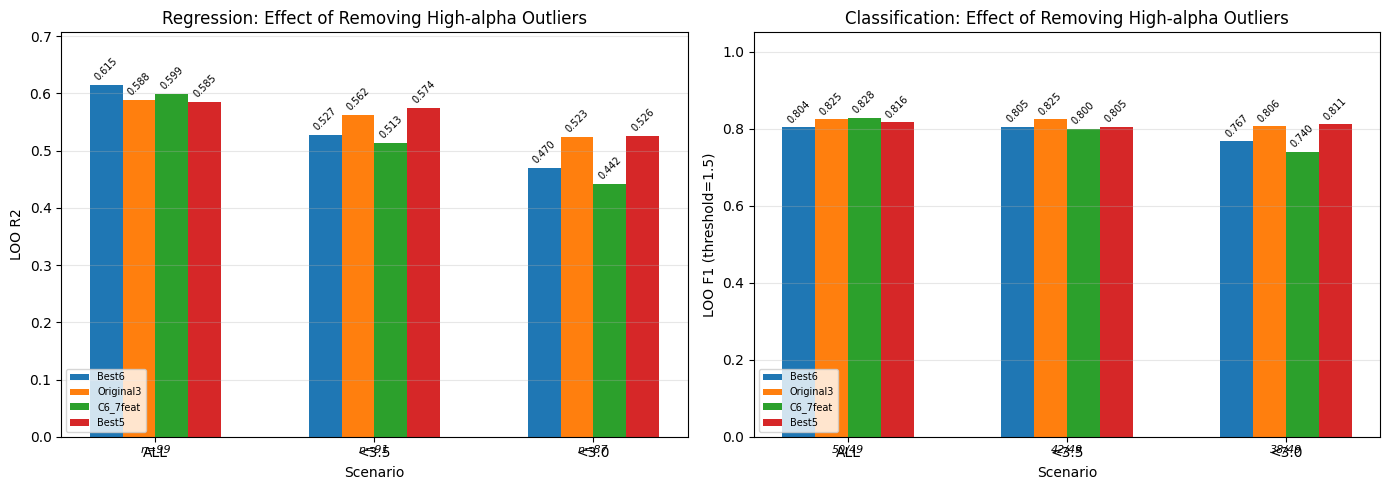

Saved: nb8_consolidated_and_outlier_analysis-results/outlier_trimming_comparison.png


In [19]:
# ============================================================
# Plot 1: R2 comparison across scenarios
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Regression R2 ---
ax = axes[0]
scenarios_order = list(SCENARIOS.keys())
feat_names = list(usable_sets.keys())
x = np.arange(len(scenarios_order))
width = 0.15

for i, fname in enumerate(feat_names):
    vals = []
    for sname in scenarios_order:
        row = reg_df[(reg_df['Scenario'] == sname) & (reg_df['FeatureSet'] == fname)]
        vals.append(row['R2'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=fname)
    # Add value labels on bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xlabel('Scenario')
ax.set_ylabel('LOO R2')
ax.set_title('Regression: Effect of Removing High-alpha Outliers')
ax.set_xticks(x + width * (len(feat_names) - 1) / 2)
ax.set_xticklabels(scenarios_order)
ax.legend(fontsize=7, loc='lower left')
ax.set_ylim(0, max(reg_df['R2']) * 1.15)
ax.grid(axis='y', alpha=0.3)

# Add sample size annotations
for i, sname in enumerate(scenarios_order):
    n = reg_df[reg_df['Scenario'] == sname]['N'].iloc[0]
    ax.text(x[i] + width * (len(feat_names) - 1) / 2, -0.02,
            f'n={n}', ha='center', va='top', fontsize=8, style='italic',
            transform=ax.get_xaxis_transform())

# --- Classification F1 ---
ax = axes[1]
for i, fname in enumerate(feat_names):
    vals = []
    for sname in scenarios_order:
        row = clf_df[(clf_df['Scenario'] == sname) & (clf_df['FeatureSet'] == fname)]
        vals.append(row['F1'].values[0] if len(row) > 0 else 0)
    bars = ax.bar(x + i * width, vals, width, label=fname)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xlabel('Scenario')
ax.set_ylabel('LOO F1 (threshold=1.5)')
ax.set_title('Classification: Effect of Removing High-alpha Outliers')
ax.set_xticks(x + width * (len(feat_names) - 1) / 2)
ax.set_xticklabels(scenarios_order)
ax.legend(fontsize=7, loc='lower left')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Add class balance annotations
for i, sname in enumerate(scenarios_order):
    rows = clf_df[clf_df['Scenario'] == sname]
    if len(rows) > 0:
        balance = rows['Pos/Neg'].iloc[0]
        ax.text(x[i] + width * (len(feat_names) - 1) / 2, -0.02,
                balance, ha='center', va='top', fontsize=8, style='italic',
                transform=ax.get_xaxis_transform())

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'outlier_trimming_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/outlier_trimming_comparison.png')

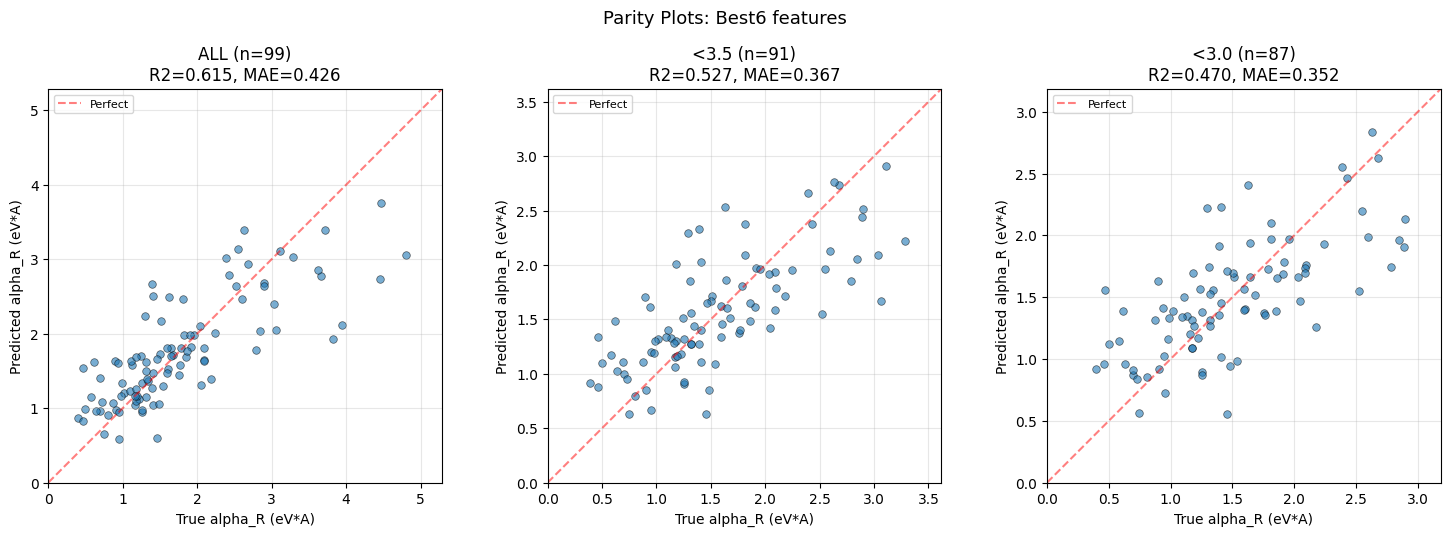

Saved: nb8_consolidated_and_outlier_analysis-results/parity_plots_outlier_trimming.png


In [20]:
# ============================================================
# Plot 2: Parity plots for Best6 across all scenarios
# ============================================================

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(5 * len(SCENARIOS), 5))
if len(SCENARIOS) == 1:
    axes = [axes]

best_feat = 'Best6' if 'Best6' in usable_sets else list(usable_sets.keys())[0]

for ax, sname in zip(axes, SCENARIOS.keys()):
    key = (sname, best_feat)
    if key in reg_predictions:
        y_true, y_pred = reg_predictions[key]
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        
        ax.scatter(y_true, y_pred, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
        lims = [0, max(max(y_true), max(y_pred)) * 1.1]
        ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect')
        ax.set_xlabel('True alpha_R (eV*A)')
        ax.set_ylabel('Predicted alpha_R (eV*A)')
        ax.set_title(f'{sname} (n={len(y_true)})\nR2={r2:.3f}, MAE={mae:.3f}')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.suptitle(f'Parity Plots: {best_feat} features', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'parity_plots_outlier_trimming.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/parity_plots_outlier_trimming.png')

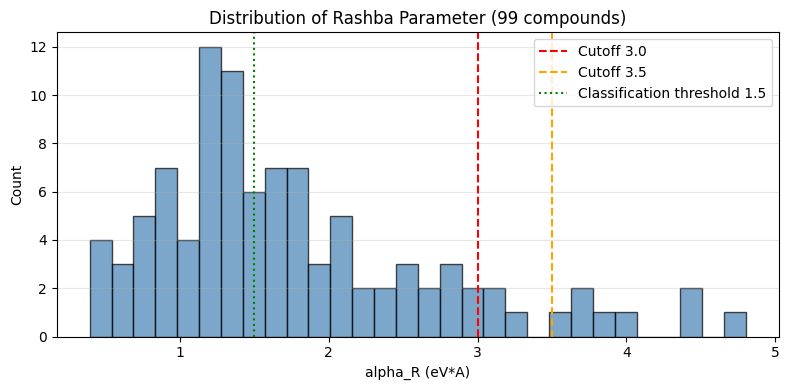

Saved: nb8_consolidated_and_outlier_analysis-results/alpha_R_distribution.png


In [21]:
# ============================================================
# Plot 3: Distribution of alpha_R with cutoff lines
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(consol_99['Rashba_parameter'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(3.0, color='red', linestyle='--', linewidth=1.5, label='Cutoff 3.0')
ax.axvline(3.5, color='orange', linestyle='--', linewidth=1.5, label='Cutoff 3.5')
ax.axvline(1.5, color='green', linestyle=':', linewidth=1.5, label='Classification threshold 1.5')
ax.set_xlabel('alpha_R (eV*A)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Rashba Parameter (99 compounds)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'alpha_R_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/alpha_R_distribution.png')

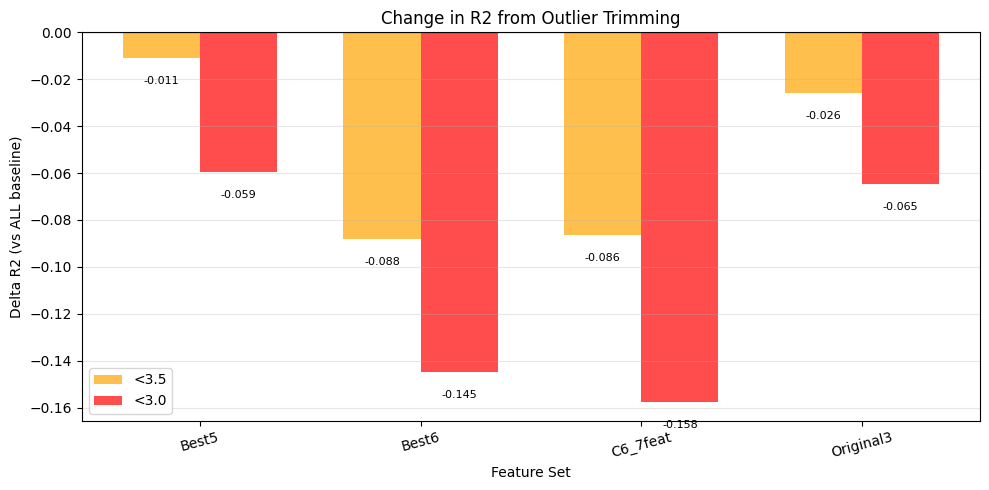

Saved: nb8_consolidated_and_outlier_analysis-results/delta_R2_from_trimming.png


In [22]:
# ============================================================
# Plot 4: Delta R2 (improvement from trimming)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# For each feature set, compute R2 change from ALL baseline
feat_names_sorted = sorted(usable_sets.keys())
x = np.arange(len(feat_names_sorted))
width = 0.35

for i, (sname, color) in enumerate([('<3.5', 'orange'), ('<3.0', 'red')]):
    deltas = []
    for fname in feat_names_sorted:
        baseline = reg_df[(reg_df['Scenario'] == 'ALL') & (reg_df['FeatureSet'] == fname)]['R2'].values
        trimmed = reg_df[(reg_df['Scenario'] == sname) & (reg_df['FeatureSet'] == fname)]['R2'].values
        if len(baseline) > 0 and len(trimmed) > 0:
            deltas.append(trimmed[0] - baseline[0])
        else:
            deltas.append(0)
    
    bars = ax.bar(x + i * width, deltas, width, label=sname, color=color, alpha=0.7)
    for bar, d in zip(bars, deltas):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.003 if d >= 0 else -0.012),
                f'{d:+.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Feature Set')
ax.set_ylabel('Delta R2 (vs ALL baseline)')
ax.set_title('Change in R2 from Outlier Trimming')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(feat_names_sorted, rotation=15)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'delta_R2_from_trimming.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR}/delta_R2_from_trimming.png')

## 5. Detailed Analysis: Which Compounds Drive the Change?

In [23]:
# ============================================================
# Residual analysis: which compounds are hardest to predict?
# ============================================================

best_feat = 'Best6' if 'Best6' in usable_sets else list(usable_sets.keys())[0]
key_all = ('ALL', best_feat)

if key_all in reg_predictions:
    y_true, y_pred = reg_predictions[key_all]
    residuals = y_true - y_pred
    abs_residuals = np.abs(residuals)
    
    # Build a residual dataframe
    resid_df = consol_99[['Formula', 'uid', 'Rashba_parameter']].copy()
    resid_df['Predicted'] = y_pred
    resid_df['Residual'] = residuals
    resid_df['AbsResidual'] = abs_residuals
    resid_df = resid_df.sort_values('AbsResidual', ascending=False)
    
    print(f'Top 15 worst predictions ({best_feat}, ALL scenario):')
    print(resid_df.head(15)[['Formula', 'Rashba_parameter', 'Predicted', 'Residual']].to_string(index=False, float_format='{:.3f}'.format))
    
    # Highlight: how many of the worst predictions are in the >3.0 group?
    top10_worst = resid_df.head(10)
    n_high = (top10_worst['Rashba_parameter'] > 3.0).sum()
    print(f'\nOf the 10 worst predictions: {n_high} have alpha_R > 3.0')
    
    resid_df.to_csv(os.path.join(RESULTS_DIR, 'residuals_all_best6.csv'), index=False)
    print(f'Saved: {RESULTS_DIR}/residuals_all_best6.csv')

Top 15 worst predictions (Best6, ALL scenario):
 Formula  Rashba_parameter  Predicted  Residual
Ga2P2Te6             3.828      1.931     1.897
    STeW             3.947      2.117     1.830
  Sn2Te2             4.804      3.055     1.749
                     4.457      2.729     1.728
   SeTeW             1.394      2.661    -1.267
 Bi2P2S6             1.406      2.504    -1.098
   BiITe             0.467      1.543    -1.076
  Pb2Te6             3.064      2.045     1.019
  BiBrSe             2.784      1.785     0.999
    HgTe             0.618      1.613    -0.995
   BiBrS             1.293      2.243    -0.950
   ISbTe             3.658      2.777     0.881
   AsISe             1.626      2.498    -0.872
  BiClTe             1.458      0.603     0.855
    ISSb             2.844      2.042     0.802

Of the 10 worst predictions: 5 have alpha_R > 3.0
Saved: nb8_consolidated_and_outlier_analysis-results/residuals_all_best6.csv


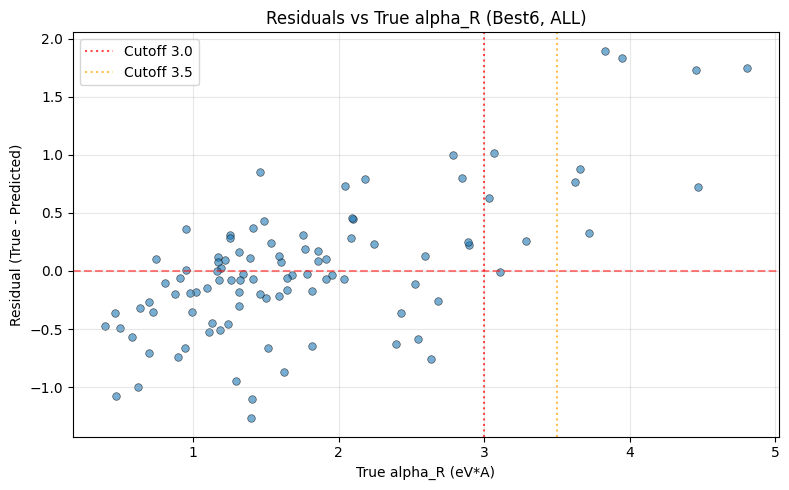

Saved: nb8_consolidated_and_outlier_analysis-results/residuals_vs_alpha.png


In [24]:
# ============================================================
# Residual vs alpha_R scatter
# ============================================================

if key_all in reg_predictions:
    y_true, y_pred = reg_predictions[key_all]
    residuals = y_true - y_pred
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(y_true, residuals, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.axvline(3.0, color='red', linestyle=':', alpha=0.7, label='Cutoff 3.0')
    ax.axvline(3.5, color='orange', linestyle=':', alpha=0.7, label='Cutoff 3.5')
    ax.set_xlabel('True alpha_R (eV*A)')
    ax.set_ylabel('Residual (True - Predicted)')
    ax.set_title(f'Residuals vs True alpha_R ({best_feat}, ALL)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, 'residuals_vs_alpha.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {RESULTS_DIR}/residuals_vs_alpha.png')

## 6. Summary Tables

In [25]:
# ============================================================
# Save summary tables
# ============================================================

reg_df.to_csv(os.path.join(RESULTS_DIR, 'regression_results.csv'), index=False)
clf_df.to_csv(os.path.join(RESULTS_DIR, 'classification_results.csv'), index=False)

print('=== REGRESSION SUMMARY ===')
print(reg_df.pivot_table(values='R2', index='FeatureSet', columns='Scenario', aggfunc='first')
      .reindex(columns=list(SCENARIOS.keys()))
      .to_string(float_format='{:.3f}'.format))

print('\n=== CLASSIFICATION SUMMARY (F1) ===')
if len(clf_df) > 0:
    print(clf_df.pivot_table(values='F1', index='FeatureSet', columns='Scenario', aggfunc='first')
          .reindex(columns=list(SCENARIOS.keys()))
          .to_string(float_format='{:.3f}'.format))

print('\n=== CLASSIFICATION SUMMARY (AUC) ===')
if len(clf_df) > 0:
    print(clf_df.pivot_table(values='AUC', index='FeatureSet', columns='Scenario', aggfunc='first')
          .reindex(columns=list(SCENARIOS.keys()))
          .to_string(float_format='{:.3f}'.format))

print(f'\nAll results saved to {RESULTS_DIR}/')

=== REGRESSION SUMMARY ===
Scenario     ALL  <3.5  <3.0
FeatureSet                  
Best5      0.585 0.574 0.526
Best6      0.615 0.527 0.470
C6_7feat   0.599 0.513 0.442
Original3  0.588 0.562 0.523

=== CLASSIFICATION SUMMARY (F1) ===
Scenario     ALL  <3.5  <3.0
FeatureSet                  
Best5      0.816 0.805 0.811
Best6      0.804 0.805 0.767
C6_7feat   0.828 0.800 0.740
Original3  0.825 0.825 0.806

=== CLASSIFICATION SUMMARY (AUC) ===
Scenario     ALL  <3.5  <3.0
FeatureSet                  
Best5      0.896 0.871 0.869
Best6      0.893 0.882 0.864
C6_7feat   0.906 0.877 0.865
Original3  0.876 0.855 0.850

All results saved to nb8_consolidated_and_outlier_analysis-results/


In [26]:
# ============================================================
# Key takeaways (auto-generated)
# ============================================================

print('=== KEY TAKEAWAYS ===')
print()

# Compare Best6 across scenarios
if 'Best6' in usable_sets:
    for sname in SCENARIOS:
        row = reg_df[(reg_df['Scenario'] == sname) & (reg_df['FeatureSet'] == 'Best6')]
        if len(row) > 0:
            print(f'Best6 @ {sname}: R2={row["R2"].values[0]:.3f}, MAE={row["MAE"].values[0]:.3f}, N={row["N"].values[0]}')
    
    # Determine if trimming helps
    r2_all = reg_df[(reg_df['Scenario'] == 'ALL') & (reg_df['FeatureSet'] == 'Best6')]['R2'].values[0]
    for sname in ['<3.5', '<3.0']:
        row = reg_df[(reg_df['Scenario'] == sname) & (reg_df['FeatureSet'] == 'Best6')]
        if len(row) > 0:
            r2_trim = row['R2'].values[0]
            delta = r2_trim - r2_all
            direction = 'HELPS' if delta > 0.01 else ('HURTS' if delta < -0.01 else 'NEUTRAL')
            print(f'  Trimming to {sname}: delta R2 = {delta:+.3f} --> {direction}')

print()
print('Note: If R2 improves with trimming, the high-alpha outliers were hurting')
print('the model (pulling predictions toward extremes or being unpredictable).')
print('If R2 drops, those points were actually informative and removing them')
print('reduces the signal-to-noise ratio.')

=== KEY TAKEAWAYS ===

Best6 @ ALL: R2=0.615, MAE=0.426, N=99
Best6 @ <3.5: R2=0.527, MAE=0.367, N=91
Best6 @ <3.0: R2=0.470, MAE=0.352, N=87
  Trimming to <3.5: delta R2 = -0.088 --> HURTS
  Trimming to <3.0: delta R2 = -0.145 --> HURTS

Note: If R2 improves with trimming, the high-alpha outliers were hurting
the model (pulling predictions toward extremes or being unpredictable).
If R2 drops, those points were actually informative and removing them
reduces the signal-to-noise ratio.


In [27]:
# ============================================================
# Final: list all output files
# ============================================================

print(f'\n=== Output files in {RESULTS_DIR}/ ===')
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f'  {f} ({size/1024:.1f} KB)')


=== Output files in nb8_consolidated_and_outlier_analysis-results/ ===
  alpha_R_distribution.png (38.6 KB)
  classification_results.csv (1.1 KB)
  delta_R2_from_trimming.png (51.4 KB)
  outlier_trimming_comparison.png (81.1 KB)
  parity_plots_outlier_trimming.png (120.5 KB)
  rashba_consolidated_205.csv (51.9 KB)
  rashba_consolidated_99.csv (21.7 KB)
  regression_results.csv (0.9 KB)
  residuals_all_best6.csv (8.2 KB)
  residuals_vs_alpha.png (57.9 KB)
